In [248]:
%pip install scqubits

Note: you may need to restart the kernel to use updated packages.


In [249]:
import sys
print(sys.executable)

/opt/anaconda3/envs/Gb_flx/bin/python


In [250]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt
import scqubits as scq
#from hamiltonian import readout_hamiltonian #qubit_resonator_hamiltonian, drive_hamiltonian
#%matplotlib qt

In [ ]:
scq.GUI()

Container(children=[Sheet(children=[Card(children=[Img(layout=None, src='data:image/png;base64,iVBORw0KGgoAAAA…

In [251]:
GHz = 1e9
MHz = 1e6
KHz = 1e3
pi = np.pi #
n_res = 200
fr = 7.0911
# Taking planck's constant to be 1 ,consequence is energy scales are in frequency
# Frequencies are taken in GHz unit meaning , 7 GHz is 7 

In [252]:
# With Qobj Ket is a column vector whereas Bra is row vector and square matrix is operator
def Ham_res(N=1):
    # N  is  number of resonator levels
    print(fr)
    H_res = fr*create(N)*destroy(N) # Readout resonator with 200 levels
    return H_res

In [253]:
def n_operator(N=1):
    # Number operator for the resonator, which counts the number of photons in the resonator. It is constructed as the product of the creation and annihilation operators, and is represented as a Qobj.
    return create(N)*destroy(N)

In [183]:
def fluxonium_hamiltonian(Ej,Ec,El,phi_ext, n_res=200):
    # Construct the Hamiltonian for the fluxonium qubit, based on the given parameters. The Hamiltonian includes the charging energy term, the inductive energy term, and the Josephson energy term, which depends on the external flux. The Hamiltonian is represented as a Qobj, which can be used for numerical simulations and analysis of the fluxonium system.
    n = num(N=n_res) # Number operator for the fluxonium charge degree of freedom
    phi = destroy(N=n_res) + create(N=n_res) # Phase operator for the fluxonium, constructed as a combination of annihilation and creation operators
    H_fluxonium = 4 * Ec * n**2 + 0.5 * El * phi**2 - Ej #* np.cos(phi - 2 * np.pi * phi_ext) # Total Hamiltonian for the fluxonium qubit
    return H_fluxonium

In [280]:
# Setting up bare fluxonium hamiltonian
m = 20 # number of transmon levels
Ej = 2.93556 #/2/pi
Ec = 0.73032 #/2/pi
El = 0.89097 #/2/pi
phi_ext = 0.5 #*2*pi
flx = scq.Fluxonium(Ej,Ec,El,phi_ext,cutoff = m)
#transmon = scq.Transmon(Ej,Ec,ng=0.5 ,ncut=15)#,cutoff = m)
#flx = fluxonium_hamiltonian(Ej,Ec,El,phi_ext, n_res=m)
H_flx = Qobj(flx.hamiltonian())
#print("fluxonium",H_flx)
n_flx = Qobj(flx.n_operator())
#print(n_flx)
#H_transmon = Qobj(transmon.hamiltonian())
##print("transmon",H_transmon)
# Eigen energies and eigenstate of transmon
#E_trans, S_trans = H_transmon.eigenstates()
#E_trans = E_trans - E_trans[0]
#print(E_trans[0],E_trans[1],E_trans[2]-E_trans[1])
E_flx, S_flx = H_flx.eigenstates()
E_flx = E_flx - E_flx[0]
print(E_flx[0],E_flx[1],E_flx[2]-E_flx[1])

0.0 0.5644637267708137 2.4426507558637542


In [281]:
# Setting up bare resonator
H_r = Ham_res(n_res)
# Eigen energies and eigenstate of resonator
E_r , S_r = H_r.eigenstates()
E_r = E_r - E_r[0]

7.0911


In [282]:
# Coupling hamilotnian
def Ham_flux_int(N=1,g = 0.1):
    # g = 0.1 is 100 MHz
    H_g = 1j * g * tensor((create(N)-destroy(N)),n_flx) 

    # To work with full hibert space , we need to take tensor products with identity operator , convention is tensor(readout,flxuonium)

    H_res_f = tensor(Ham_res(N),qeye(m))
    H_flx_f = tensor(qeye(N),H_flx)
    #H_trans_f = tensor(qeye(N),H_transmon)

    # Interaction hamiltonian

    H_f = H_res_f + H_flx_f + H_g
    #H_trans_f = H_res_f + H_trans_f + H_g
    return H_f

In [283]:
def Ham_trans_int(N=1,g = 0.1):
    # g = 0.1 is 100 MHz
    H_g = 1j * g * tensor((create(N)-destroy(N)),n_flx) 

    # To work with full hibert space , we need to take tensor products with identity operator , convention is tensor(readout,flxuonium)

    H_res_f = tensor(Ham_res(N),qeye(m))
    H_flx_f = tensor(qeye(N),H_flx)
    H_trans_f = tensor(qeye(N),H_transmon)

    # Interaction hamiltonian

    #H_f = H_res_f + H_flx_f + H_g
    H_trans_f = H_res_f + H_trans_f + H_g
    return H_trans_f

In [258]:
# Next for branch reference we assign energy levels and eigens states of 0 resontor population

In [284]:
E_flx[0:105]

array([ 0.        ,  0.56446373,  3.00711448,  5.12156954,  7.66052365,
       10.29103667, 12.9767429 , 15.64577459, 18.22238661, 20.68371255,
       23.00810942, 25.05121643, 27.17157482, 29.09963706, 30.85295633,
       33.37691172, 34.44659836, 38.19846147, 40.78798904, 42.91687684])

In [285]:
#E_trans[20:]

In [286]:
Ham_flux_final = Ham_flux_int(n_res,0.09)

7.0911


In [287]:
Ham_trans_final = Ham_trans_int(n_res,0.09)

7.0911


NameError: name 'H_transmon' is not defined

In [302]:
E_rf, S_rf = Ham_flux_final.eigenstates()

In [303]:
E_rf=E_rf-E_rf[0]
print(E_rf[0],E_rf[1],E_rf[2]-E_rf[1])

0.0 0.564208791309389 2.441965623208747


In [20]:
#E_rt, S_rt = Ham_trans_final.eigenstates()

In [288]:
E_rt=E_rt-E_rt[0]
print(E_rt[0],E_rt[1],E_rt[2]-E_rt[1])

NameError: name 'E_rt' is not defined

In [304]:
# Dispersive shift for the particular choice of parameters
print(E_rf[5],E_rf[1],E_rf[4],E_rf[0], E_rf[2], E_rf[3])
E_rf[5]-E_rf[1]-E_rf[4]+E_rf[0]

7.638422564386423 0.564208791309389 7.091488909810162 0.0 3.006174414518136 5.119745569402361


np.float64(-0.017275136733128527)

In [305]:
indx_0 = [] # Indices corresponding fluxonium level with nr=0
for i in range(0,20):
    temp =1
    for j in range(0,500):
        if np.abs(E_rf[j]-E_flx[i])<temp:
            temp = np.abs(E_rf[j]-E_flx[i])
            temp1 = j
    indx_0.append(temp1)

print(indx_0)
# Next step is to find indices with state nr+1
# For now I am just considering Fluxonium Ground and Excited level branch
#indx_0 = indx_0[:2]        

[0, 1, 2, 3, 6, 8, 10, 14, 17, 20, 25, 28, 32, 37, 40, 45, 49, 58, 65, 71]


In [306]:
np.size(indx_0) , np.size(E_rf)

(20, 4000)

In [307]:
indx_mat_flux = []
cr_opr = tensor(create(n_res),qeye(m))# creation operator for resonator photon 
branch_num = 15 # number of branches we explore
lvls=np.size(E_rf)
#for k in range(200):
#    temp_indx= []
for j in range(branch_num):
    temp2 = indx_0[j]
    temp_indx = [temp2]
    for k in range(151): # Number of photons to consider
        temp = 0
        B = S_rf[temp2]  # Previous state in the branch
        for i in range(lvls):
            A = S_rf[i] # States to be scanned
            # oeverlap of state with creation of next resonator photon  ovrlap = (cr_opr*B).overlap(A) and ovrlap_c = np.conj(ovrlap`)
            ovrlap = (cr_opr*B).overlap(A)
            expct = ovrlap*np.conj(ovrlap)
            #expct = (np.abs(A.dag()*cr_opr*B))**2
            if expct > temp:
                temp = expct
                temp2 = i
        temp_indx.append(temp2)
    indx_mat_flux.append(temp_indx)        

In [308]:
indx_mat_trans = []
cr_opr = tensor(create(n_res),qeye(m))# creation operator for resonator photon 
branch_num = 30 # number of branches we explore
lvls=np.size(E_rt)
#for k in range(200):
#    temp_indx= []
for j in range(branch_num):
    temp2 = indx_0[j]
    temp_indx = [temp2]
    for k in range(151): # Number of photons to consider
        temp = 0
        B = S_rt[temp2]  # Previous state in the branch
        for i in range(lvls):
            A = S_rt[i] # States to be scanned
            # oeverlap of state with creation of next resonator photon  ovrlap = (cr_opr*B).overlap(A) and ovrlap_c = np.conj(ovrlap`)
            ovrlap = (cr_opr*B).overlap(A)
            expct = ovrlap*np.conj(ovrlap)
            #expct = (np.abs(A.dag()*cr_opr*B))**2
            if expct > temp:
                temp = expct
                temp2 = i
        temp_indx.append(temp2)
    indx_mat_trans.append(temp_indx)        

NameError: name 'E_rt' is not defined

In [309]:
np.size(indx_mat_flux[2]) , E_rf[2]

(152, np.float64(3.006174414518136))

In [310]:
np.size

<function size at 0x106abfbb0>

In [311]:
branch = E_rf[indx_mat_flux]

IndexError: index 15 is out of bounds for axis 0 with size 15

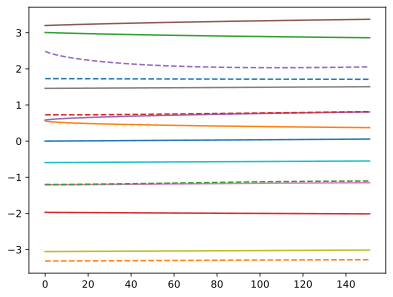

In [312]:
plt.figure()
for i in range(branch_num):
    br_e = [x%fr for x in branch[i]]
    #br_e = [x if x<=3.75 else 3.75-x for x in br_e]
    for a,x in enumerate(br_e):
        if x<=fr/2:
            br_e[a] = x
        else:
            br_e[a] = x-fr
    #br_e = [x if x<=3.75 else x-7.5 for x in br_e]
    if i<10:
        plt.plot(br_e, label = f'{i}')
    elif 10<=i<20:
        plt.plot(br_e, label = f'{i}',ls='--')
    else:
        plt.plot(br_e, label = f'{i}',ls=':')
#plt.xlim(0,170)
#plt.ylim(-3.74,3.74)
plt.legend()
plt.title("Coupling = 90MHz; Freq of rr = 7.0911 GHz")

In [314]:
branch = E_rf[indx_mat_trans]

In [315]:
plt.figure()
for i in range(branch_num-29):
    br_e = [x%fr for x in branch[i]]
    #br_e = [x if x<=3.75 else 3.75-x for x in br_e]
    for a,x in enumerate(br_e):
        if x<=fr/2:
            br_e[a] = x
        else:
            br_e[a] = x-fr
    #br_e = [x if x<=3.75 else x-7.5 for x in br_e]
    if i<10:
        plt.plot(br_e, label = f'{i}')
    elif 10<=i<20:
        plt.plot(br_e, label = f'{i}',ls='--')
    else:
        plt.plot(br_e, label = f'{i}',ls=':')
#plt.xlim(0,170)
#plt.ylim(-3.74,3.74)
plt.legend()
plt.title("Coupling = 90MHz; Freq of rr = 7.0911 GHz")

IndexError: index 0 is out of bounds for axis 0 with size 0

<Figure size 640x480 with 0 Axes>

In [316]:
# de_opr = tensor(destroy(n_res),qeye(m))
# Nq = []
# Nr = []
# for k in range(branch_num):
#     nq = []
#     nr = []
#     for i,j in enumerate(indx_mat[k]):
#         C = S_rf[j]
#         exct_num = 0
#         for l in range(n_res):
#             for s in range(m):
#                 D = tensor(S_r[l],S_flx[s])
#                 exct_num = s*(abs(D.dag()*C))**2 + exct_num
#         nq.append(exct_num)
#         nr.append(abs(C.dag()*cr_opr*de_opr*C))
#     Nq.append(nq)
#     Nr.append(nr)

de_opr = tensor(destroy(n_res), qeye(m))
Nq = []
Nr = []

for k in range(branch_num):
    nq = []
    nr = []

    for i, j in enumerate(indx_mat_flux[k]):
        C = S_rf[j]
        exct_num = 0

        for l in range(n_res):
            for s in range(m):
                D = tensor(S_r[l], S_flx[s])

                # compute |<D|C>|^2
                overlap = D.overlap(C)
                exct_num += s * np.abs(overlap)**2

        nq.append(exct_num)

        # number operator expectation value
        nr.append(np.abs((C.dag() * cr_opr * de_opr * C)))#.full()[0, 0]))

    Nq.append(nq)
    Nr.append(nr)


IndexError: list index out of range

In [277]:
de_opr = tensor(destroy(n_res), qeye(m))
Nq = []
Nr = []

for k in range(branch_num):
    nq = []
    nr = []

    for i, j in enumerate(indx_mat_flux[k]):
        C = S_rf[j]
        exct_num = 0

        for l in range(n_res):
            for s in range(m):
                D = tensor(S_r[l], S_flx[s])

                # compute |<D|C>|^2
                overlap = D.overlap(C)
                exct_num += s * np.abs(overlap)**2

        nq.append(exct_num)

        # number operator expectation value
        nr.append(np.abs((C.dag() * cr_opr * de_opr * C)))#.full()[0, 0]))

    Nq.append(nq)
    Nr.append(nr)


IndexError: list index out of range

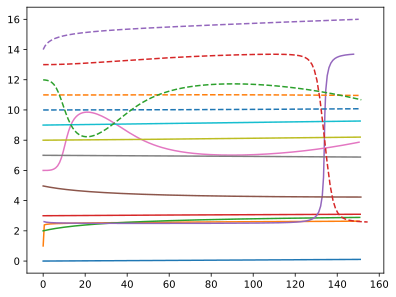

In [318]:
plt.figure()
for k in range(branch_num):
    if k<10:
        plt.plot(Nr[k],Nq[k],label = f"{k}")
    elif 10<=k<20:
        plt.plot(Nr[k],Nq[k],label = f"{k}",ls='--')
    else:
        plt.plot(Nr[k],Nq[k],label = f"{k}",ls=':')
plt.legend()
        #plt.plot(Nr_11,Nt_11)
#plt.plot(Nr_12,Nt_12)

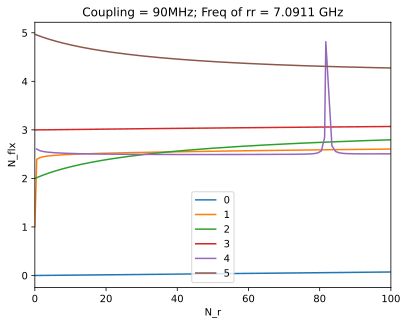

In [239]:
plt.figure()
for k in [0,1,2,3,4,5]: # 7,11,13,14,25,28
    if k<10:
        plt.plot(Nr[k],Nq[k],label = f"{k}")
    else:
        plt.plot(Nr[k],Nq[k],label = f"{k}",ls='--')
plt.legend()
plt.xlabel('N_r')
plt.ylabel('N_flx')
plt.xlim(0,100)
plt.title("Coupling = 90MHz; Freq of rr = 7.0911 GHz")
plt.legend()

Text(0.5, 1.0, 'Coupling = 90MHz; Freq of rr = 7.0911 GHz')

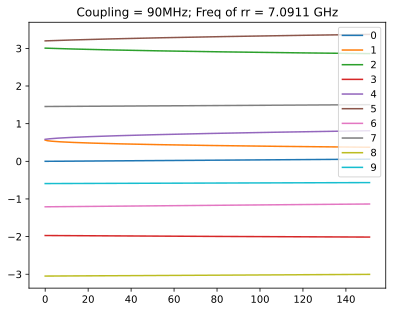

In [240]:
plt.figure()
for i in range(10):
    br_e = [x%7.0911 for x in branch[i]]
    #br_e = [x if x<=3.75 else 3.75-x for x in br_e]
    for a,x in enumerate(br_e):
        if x<=7.0911/2:
            br_e[a] = x
        else:
            br_e[a] = x-7.0911
    #br_e = [x if x<=3.75 else x-7.5 for x in br_e]
    if i<10:
        plt.plot(br_e, label = f'{i}')
    elif 10<=i<20:
        plt.plot(br_e, label = f'{i}',ls='--')
    else:
        plt.plot(br_e, label = f'{i}',ls=':')
#plt.xlim(0,170)
#plt.ylim(-3.74,3.74)
plt.legend()
plt.title("Coupling = 90MHz; Freq of rr = 7.0911 GHz")

In [ ]:
E_flx